In [2]:
import math

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST

from torch.amp import autocast, GradScaler

In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_channel, out_channel):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channel, out_channel, 3, padding=1),
            nn.GroupNorm(8, out_channel),
            nn.SiLU()
        )

        self.time_embedding = nn.Linear(128, out_channel)

        self.conv2 = nn.Sequential(
            nn.Conv2d(out_channel, out_channel, 3, padding=1),
            nn.GroupNorm(8, out_channel),
            nn.SiLU()
        )

        self.skip = nn.Conv2d(in_channel, out_channel, 1)

    def forward(self, x, t):
        h = self.conv1(x)
        h = h + self.time_embedding(t)[:, :, None, None]
        h = self.conv2(h)
        h = h + self.skip(x)
        return h

In [4]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        embed = math.log(10000) / (half_dim - 1)
        embed = torch.exp(torch.arange(half_dim, device=device) * -embed)
        embed = t[:, None] * embed[None, :]
        embed = torch.cat((embed.sin(), embed.cos()), dim=-1)
        return embed

In [5]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.time_embedding = nn.Sequential(
            SinusoidalPositionEmbeddings(128),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 128)
        )

        self.label_embedding = nn.Embedding(10, 128)

        self.encoder1 = ConvBlock(1, 32)
        self.encoder2 = ConvBlock(32, 64)
        self.encoder3 = ConvBlock(64, 128)

        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(128, 256)

        self.upconv3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.decoder3 = ConvBlock(256, 128)
        self.upconv2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.decoder2 = ConvBlock(128, 64)
        self.upconv1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.decoder1 = ConvBlock(64, 32)

        self.out = nn.Sequential(
            nn.GroupNorm(8, 32),
            nn.SiLU(),
            nn.Conv2d(32, 1, 1)
        )

    def forward(self, x, t, label=None):
        t_embed = self.time_embedding(t)

        if label is not None:
            t_embed = t_embed + self.label_embedding(label)

        # Encoder
        encode_1 = self.encoder1(x, t_embed)                   # 32x32
        encode_2 = self.encoder2(self.pool(encode_1), t_embed) # 16x16
        encode_3 = self.encoder3(self.pool(encode_2), t_embed) # 8x8

        # Bottleneck
        bottleneck = self.bottleneck(self.pool(encode_3), t_embed) # 4x4

        # Decoder
        decode_3 = self.upconv3(bottleneck) # 8x8
        decode_3 = self.decoder3(torch.cat((decode_3, encode_3), dim=1), t_embed)

        decode_2 = self.upconv2(decode_3) # 16x16
        decode_2 = self.decoder2(torch.cat((decode_2, encode_2), dim=1), t_embed)

        decode_1 = self.upconv1(decode_2) # 32x32
        decode_1 = self.decoder1(torch.cat((decode_1, encode_1), dim=1), t_embed)

        out = self.out(decode_1)
        return out

In [7]:
class FlowMatching(nn.Module):
    def __init__(self):
        super().__init__()

        self.unet = UNet().to(device)
        self.optimizer = optim.Adam(self.unet.parameters(), lr=lr)
        self.scaler = GradScaler('cuda')

    def train(self, x_0, labels):
        x_0 = images
        B, C, H, W = x_0.shape

        t = torch.rand((B, ), device=device) # (B, )
        z = torch.randn_like(x_0, device=device)   # (B, 1, 32, 32)

        x_t = self.add_noise(x_0, z, t)

        drift = z - x_0

        with autocast('cuda'):
            predicted_drift = self.unet(x_t, t, labels)
            loss = F.mse_loss(predicted_drift, drift)

        self.optimizer.zero_grad()
        self.scaler.scale(loss).backward()
        self.scaler.step(self.optimizer)
        self.scaler.update()

        return loss

    def add_noise(self, x_0, z, t):
        t = t.view(-1, 1, 1, 1) # (B, 1, 1, 1)
        x_t = t * z + (1 - t) * x_0 # Linear Interpolation
        return x_t

    def sample(self, num_steps=16, label=None):
        x = torch.randn((1, 1, 32, 32), device=device)
        time_step = torch.linspace(1, 0, time_steps + 1)[:-1] # [1.0, 0.9375, 0.875, ..., 0.0625]
        dt = 1.0 / num_steps

        for t in time_step:
            t = torch.tensor([t], device=device)
            predicted_drift = self.unet(x, t, label)
            x = x - dt * predicted_drift # noise -> image
        return x

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

epochs = 80
batch_size = 256
image_size = 32
lr = 0.0005

time_steps = 16

In [9]:
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor()
])

In [10]:
train_data = MNIST("/", train=True, transform=transform, download=True)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

In [11]:
model = FlowMatching()

In [12]:
def save_model_params(model, epoch):
    file_name = f"Flow_Matching_MNIST_ep{epoch}.pth"
    torch.save({
        'unet': model.unet.state_dict(),
        'optimizer': model.optimizer.state_dict()
    }, file_name)
    print(f"Model saved: {file_name}")

In [13]:
def load_model_params(model, check_point_path):
    checkpoint = torch.load(check_point_path, map_location=device)
    model.unet.load_state_dict(checkpoint['unet'])
    model.optimizer.load_state_dict(checkpoint['optimizer'])

# if pretrained
# check_point_path = "Flow_Matching_MNIST_ep80.pth"
check_point_path = ""

if check_point_path:
    load_model_params(model, check_point_path)

In [25]:
########## Train ##########

for epoch in range(1, epochs + 1):
    total_loss = 0

    for batch_index, (images, labels) in enumerate(train_loader, 1):
        images = images.to(device) # (B, 1, 32, 32)
        labels = labels.to(device) # (B, )

        loss = model.train(images, labels)
        total_loss += loss.item()

    total_loss /= batch_index

    print(f"epoch: {epoch:3d} | loss: {total_loss:7.5f}")

    if epoch % 10 == 0:
        save_model_params(model, epoch)

epoch:   1 | loss: 0.05520


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.


KeyboardInterrupt



In [ ]:
"""
epoch:   1 | loss: 0.12902
epoch:   2 | loss: 0.07784
epoch:   3 | loss: 0.07160
epoch:   4 | loss: 0.06841
epoch:   5 | loss: 0.06608
epoch:   6 | loss: 0.06493
epoch:   7 | loss: 0.06424
epoch:   8 | loss: 0.06243
epoch:   9 | loss: 0.06226
epoch:  10 | loss: 0.06156
Model saved: Flow_Matching_MNIST_ep10.pth
epoch:  11 | loss: 0.06127
epoch:  12 | loss: 0.06106
epoch:  13 | loss: 0.06072
epoch:  14 | loss: 0.05989
epoch:  15 | loss: 0.05991
epoch:  16 | loss: 0.05984
epoch:  17 | loss: 0.05938
epoch:  18 | loss: 0.05892
epoch:  19 | loss: 0.05888
epoch:  20 | loss: 0.05869
Model saved: Flow_Matching_MNIST_ep20.pth
epoch:  21 | loss: 0.05858
epoch:  22 | loss: 0.05837
epoch:  23 | loss: 0.05857
epoch:  24 | loss: 0.05824
epoch:  25 | loss: 0.05790
epoch:  26 | loss: 0.05801
epoch:  27 | loss: 0.05755
epoch:  28 | loss: 0.05761
epoch:  29 | loss: 0.05763
Model saved: Flow_Matching_MNIST_ep30.pth
epoch:  30 | loss: 0.05753
epoch:  31 | loss: 0.05743
epoch:  32 | loss: 0.05733
epoch:  33 | loss: 0.05731
epoch:  34 | loss: 0.05697
epoch:  35 | loss: 0.05729
epoch:  36 | loss: 0.05696
epoch:  37 | loss: 0.05669
epoch:  38 | loss: 0.05675
epoch:  39 | loss: 0.05671
epoch:  40 | loss: 0.05659
Model saved: Flow_Matching_MNIST_ep40.pth
epoch:  41 | loss: 0.05640
epoch:  42 | loss: 0.05661
epoch:  43 | loss: 0.05659
epoch:  44 | loss: 0.05624
epoch:  45 | loss: 0.05649
epoch:  46 | loss: 0.05626
epoch:  47 | loss: 0.05628
epoch:  48 | loss: 0.05618
epoch:  49 | loss: 0.05644
epoch:  50 | loss: 0.05623
Model saved: Flow_Matching_MNIST_ep50.pth
epoch:  51 | loss: 0.05596
epoch:  52 | loss: 0.05596
epoch:  53 | loss: 0.05605
epoch:  54 | loss: 0.05605
epoch:  55 | loss: 0.05603
epoch:  56 | loss: 0.05584
epoch:  57 | loss: 0.05569
epoch:  58 | loss: 0.05577
epoch:  59 | loss: 0.05569
epoch:  60 | loss: 0.05594
Model saved: Flow_Matching_MNIST_ep60.pth
epoch:  61 | loss: 0.05593
epoch:  62 | loss: 0.05562
epoch:  63 | loss: 0.05556
epoch:  64 | loss: 0.05553
epoch:  65 | loss: 0.05547
epoch:  66 | loss: 0.05560
epoch:  67 | loss: 0.05547
epoch:  68 | loss: 0.05551
epoch:  69 | loss: 0.05548
epoch:  70 | loss: 0.05547
Model saved: Flow_Matching_MNIST_ep70.pth
epoch:  71 | loss: 0.05510
epoch:  72 | loss: 0.05549
epoch:  73 | loss: 0.05539
epoch:  74 | loss: 0.05551
epoch:  75 | loss: 0.05519
epoch:  76 | loss: 0.05528
epoch:  77 | loss: 0.05514
epoch:  78 | loss: 0.05500
epoch:  79 | loss: 0.05509
epoch:  80 | loss: 0.05520
Model saved: Flow_Matching_MNIST_ep80.pth
"""

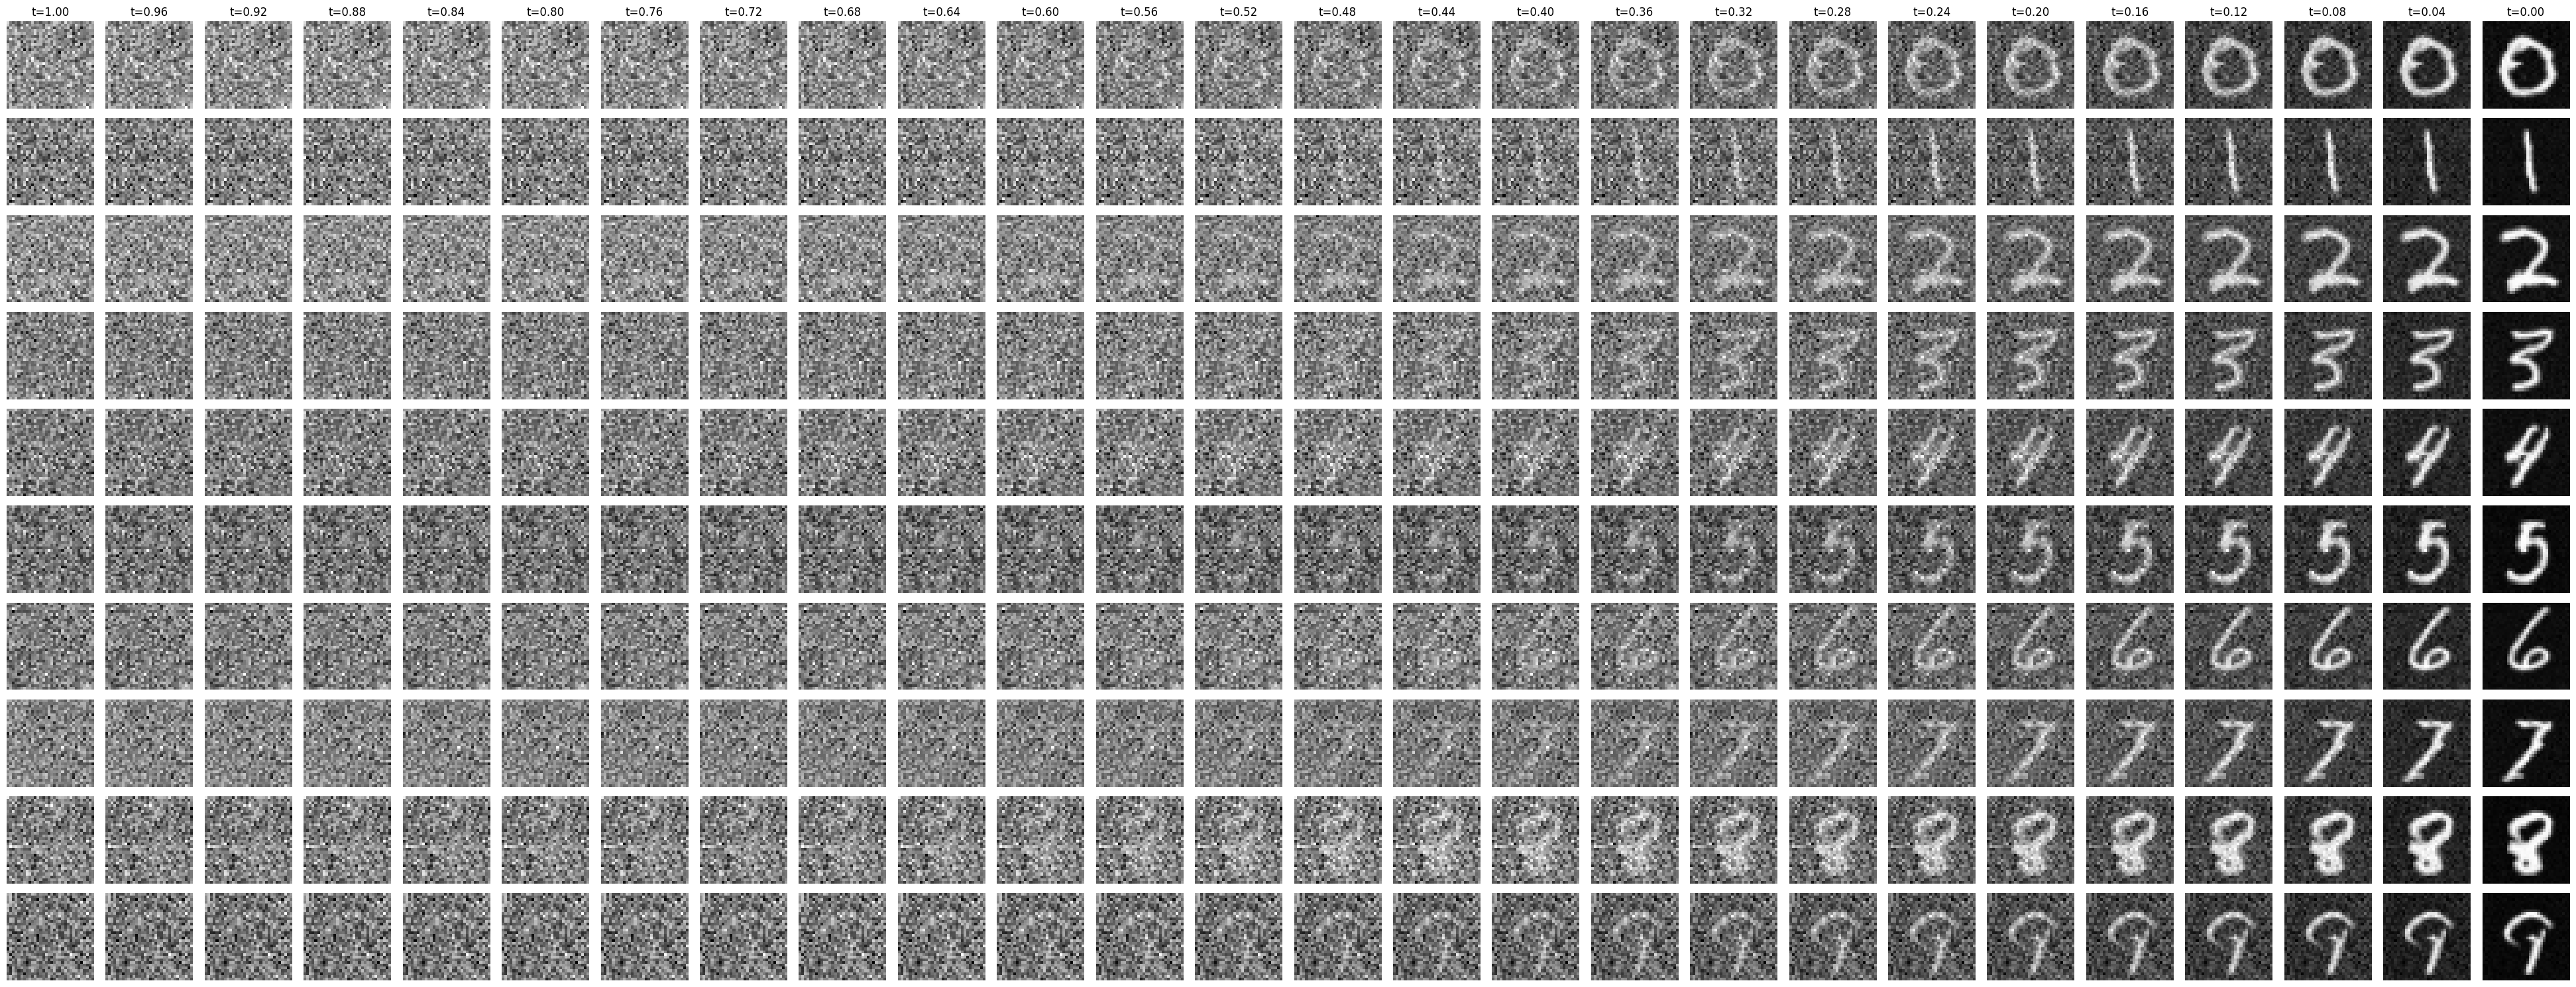

In [39]:
import matplotlib.pyplot as plt

def visualize_denoising_process(model, num_steps):
    model.unet.eval()
    classes = range(10)
    fig, axes = plt.subplots(10, num_steps, figsize=(num_steps * 1.5, 15))

    time_steps = torch.linspace(1.0, 0.0, num_steps).to(device)
    dt = 1.0 / num_steps

    with torch.no_grad():
        for i, label_idx in enumerate(classes):
            x = torch.randn((1, 1, 32, 32), device=device)
            label = torch.tensor([label_idx], device=device)

            step_count = 0
            for t in time_steps:
                img = x.squeeze().cpu().numpy()
                axes[i, step_count].imshow(img, cmap='gray')
                axes[i, step_count].axis('off')

                if i == 0:
                    axes[i, step_count].set_title(f"t={t.item():.2f}")

                t_tensor = torch.tensor([t], device=device)
                predicted_drift = model.unet(x, t_tensor, label)

                x = x - predicted_drift * dt
                step_count += 1
                if step_count >= num_steps: break

    plt.tight_layout()
    plt.show()

visualize_denoising_process(model, num_steps=25 + 1)